## [HW2] Linear Kalman Filter

Frolova AI

`https://github.com/kicchhi/Advanced-Robotics/tree/main`

**Задача:** Используя смартфон, пройти определенную дистанцию на улице, записать данные и с помощью фильтра Калмана объединить показания GPS и акселерометра для
точной оценки пройденного пути.
Сбор данных: Вам необходимо выйти на улицу (где есть хороший прием GPS) и пройти/пробежать по прямой дистанцию около 100–150 метров. Записать sensor data в csv-файл
в мобильном приложении (например, Physics Toolbox Sensor Suite (Android/iOS), Sensor Logger, Phyphox, etc.):
    - GPS (Location): Широта (Latitude), Долгота (Longitude).
    - Linear Accelerometer: Ускорение по осям X, Y, Z без учета гравитации (в некоторых приложениях это называется User Acceleration). Важно: если вы запишете обычный
акселерометр, вам придется вручную вычитать вектор гравитации 9.8 м/с².

Реализация в Jupyter/Colab:

1. Загрузка данных: Импортируйте свой CSV. Рассчитайте дистанцию, измеренную чисто по GPS (используйте формулу Haversine или простую евклидову метрику,
переведя координаты в метры относительно точки старта). Это будет ваше измерение z.
2. Определение параметров шума (Hint):
• std_acc (шум процесса): Оцените стандартное отклонение акселерометра, взяв участок данных, где телефон лежал неподвижно (или двигался равномерно).
• std_meas (шум измерения): Оцените точность GPS (можно взять паспортные данные, например, 3-5 метров, или посчитать разброс точек, когда вы стояли
на месте).
3. Фильтр Калмана:
• Реализуйте линейный фильтр Калмана.
• Вектор состояния: 𝒙 = 𝒑𝒐𝒔𝒊𝒕𝒊𝒐𝒏, 𝒗𝒆𝒍𝒐𝒄𝒊𝒕𝒚 𝑻.
• Вход управления (u): Данные линейного акселерометра (спроецированные на направление движения).
4. Результат:
• Постройте график: Измеренная дистанция (GPS) vs Предсказанная дистанция (KF). Загрузите ваши CSV- и ipynb- файлы в Github.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Основные функции

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Расстояние между GPS точками в метрах"""
    R = 6371000
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    
    a = np.sin(delta_phi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

def read_sensor_data(csv_path):
    """Читаем CSV файл"""
    df = pd.read_csv(csv_path, sep=';', decimal=',')
    df.columns = df.columns.str.strip()
    
    time = df['time'].values
    lat = df['Latitude'].values
    lon = df['Longitude'].values
    acc_x = df['ax'].values
    acc_y = df['ay'].values
    acc_z = df['az'].values
    
    print(f"Загружено {len(time)} записей")
    print(f"Время: {time[0]:.2f} - {time[-1]:.2f} с")
    print(f"Первая GPS точка: lat={lat[1]:.6f}, lon={lon[1]:.6f}")
    
    return time, lat, lon, acc_x, acc_y, acc_z

def gps_to_meters(lat, lon):
    """GPS координаты в метры от старта"""
    n = len(lat)
    distances = np.zeros(n)
    
    # Первая ненулевая точка - старт
    # Сделала так, потому что некоторые измерения в начале были нулевыми
    start_idx = 1  # вторая точка (индекс 1) уже с координатами
    ref_lat, ref_lon = lat[start_idx], lon[start_idx]
    
    for i in range(start_idx, n):
        distances[i] = haversine_distance(ref_lat, ref_lon, lat[i], lon[i])
    
    print(f"Дистанция по GPS: {distances[-1]:.1f} м")
    return distances

def estimate_noise(time, acc_x, acc_y, acc_z):
    """Оценка шумов из первых 100 точек"""
    n_static = 100
    acc_mag = np.sqrt(acc_x[:n_static]**2 + acc_y[:n_static]**2 + acc_z[:n_static]**2)
    std_acc = np.std(acc_mag)
    std_meas = 3.0  # типичный шум GPS
    
    print(f"Шум акселерометра: {std_acc:.4f} м/с²")
    print(f"Шум GPS: {std_meas:.1f} м")
    return std_meas, std_acc

class KalmanFilter:
    """Фильтр Калмана"""
    def __init__(self, dt, std_acc, std_meas):
        self.dt = dt
        self.F = np.array([[1, dt], [0, 1]])
        self.B = np.array([[0.5*dt**2], [dt]])
        self.H = np.array([[1, 0]])
        
        self.Q = np.array([[std_acc**2 * dt**4/4, std_acc**2 * dt**3/2],
                          [std_acc**2 * dt**3/2, std_acc**2 * dt**2]])
        self.R = np.array([[std_meas**2]])
        
        self.x = np.array([[0], [0]])
        self.P = np.eye(2) * 10
    
    def predict(self, u):
        self.x = self.F @ self.x + self.B * u
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x
    
    def update(self, z):
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(2) - K @ self.H) @ self.P
        return self.x

def run_kalman(time, gps_dist, acc_x):
    """Запуск фильтра"""
    dt = np.mean(np.diff(time))
    std_meas, std_acc = estimate_noise(time, acc_x, acc_y, acc_z)
    
    kf = KalmanFilter(dt, std_acc, std_meas)
    pos = np.zeros(len(time))
    vel = np.zeros(len(time))
    
    for i in range(len(time)):
        kf.predict(acc_x[i])
        if i > 0 and gps_dist[i] > 0:
            kf.update(np.array([[gps_dist[i]]]))
        pos[i] = kf.x[0, 0]
        vel[i] = kf.x[1, 0]
    
    return pos, vel

# Построение графиков

In [ ]:
def plot_results(time, gps_dist, kf_pos, kf_vel, acc_x, lat, lon):
    """Графики"""

    # Первые сто точек
    plt.figure(figsize=(14, 4))
    plt.plot(time[:100], gps_dist[:100], 'b.-', label='GPS')
    plt.plot(time[:100], kf_pos[:100], 'r.-', label='Калман')
    plt.xlabel('Время (с)')
    plt.ylabel('Расстояние (м)')
    plt.title('Начальный участок пути')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14, 12))
    
    # Скорость
    plt.subplot(4, 1, 2)
    plt.plot(time, kf_vel, 'g-', label='Скорость', linewidth=2)
    plt.ylabel('Скорость (м/с)')
    plt.title('Оценка скорости')
    plt.legend()
    plt.grid(True)
    
    # Ускорение
    plt.subplot(4, 1, 3)
    plt.plot(time, acc_x, 'm-', label='Ускорение (ось X)', alpha=0.7)
    plt.ylabel('Ускорение (м/с^2)')
    plt.title('Данные акселерометра')
    plt.legend()
    plt.grid(True)
    
    # GPS
    plt.subplot(4, 1, 4)
    plt.plot(lon[1:], lat[1:], 'b.-', alpha=0.5, markersize=2)
    plt.plot(lon[1], lat[1], 'go', label='Старт', markersize=8)
    plt.plot(lon[-1], lat[-1], 'ro', label='Финиш', markersize=8)
    plt.xlabel('Долгота')
    plt.ylabel('Широта')
    plt.title('GPS трек')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

Загружено 2905 записей
Время: 0.06 - 291.92 с
Первая GPS точка: lat=55.754442, lon=48.742093
Дистанция по GPS: 375.7 м
Шум акселерометра: 1.1747 м/с²
Шум GPS: 3.0 м

РЕЗУЛЬТАТЫ
Пройдено по GPS: 375.7 м
Пройдено по Калману: 374.8 м
Макс. скорость: 2.68 м/с (9.63 км/ч)
Ошибка (RMSE): 0.81 м


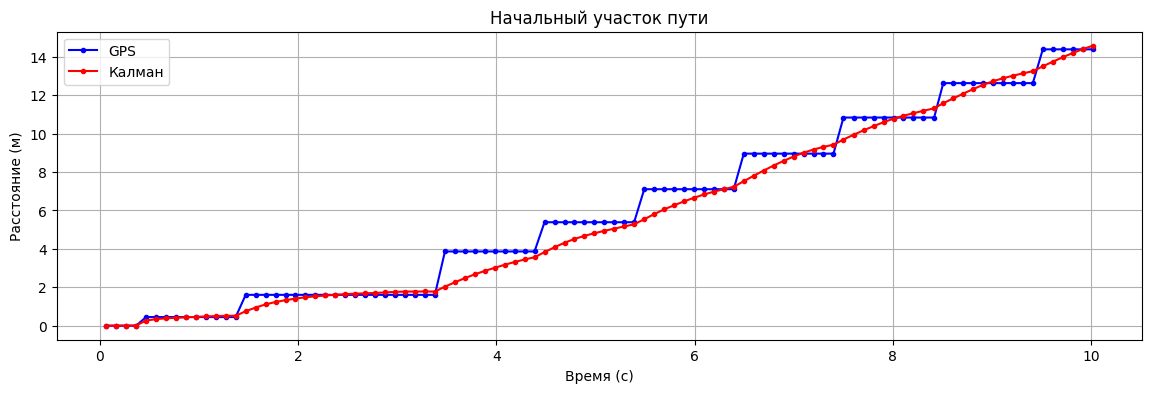

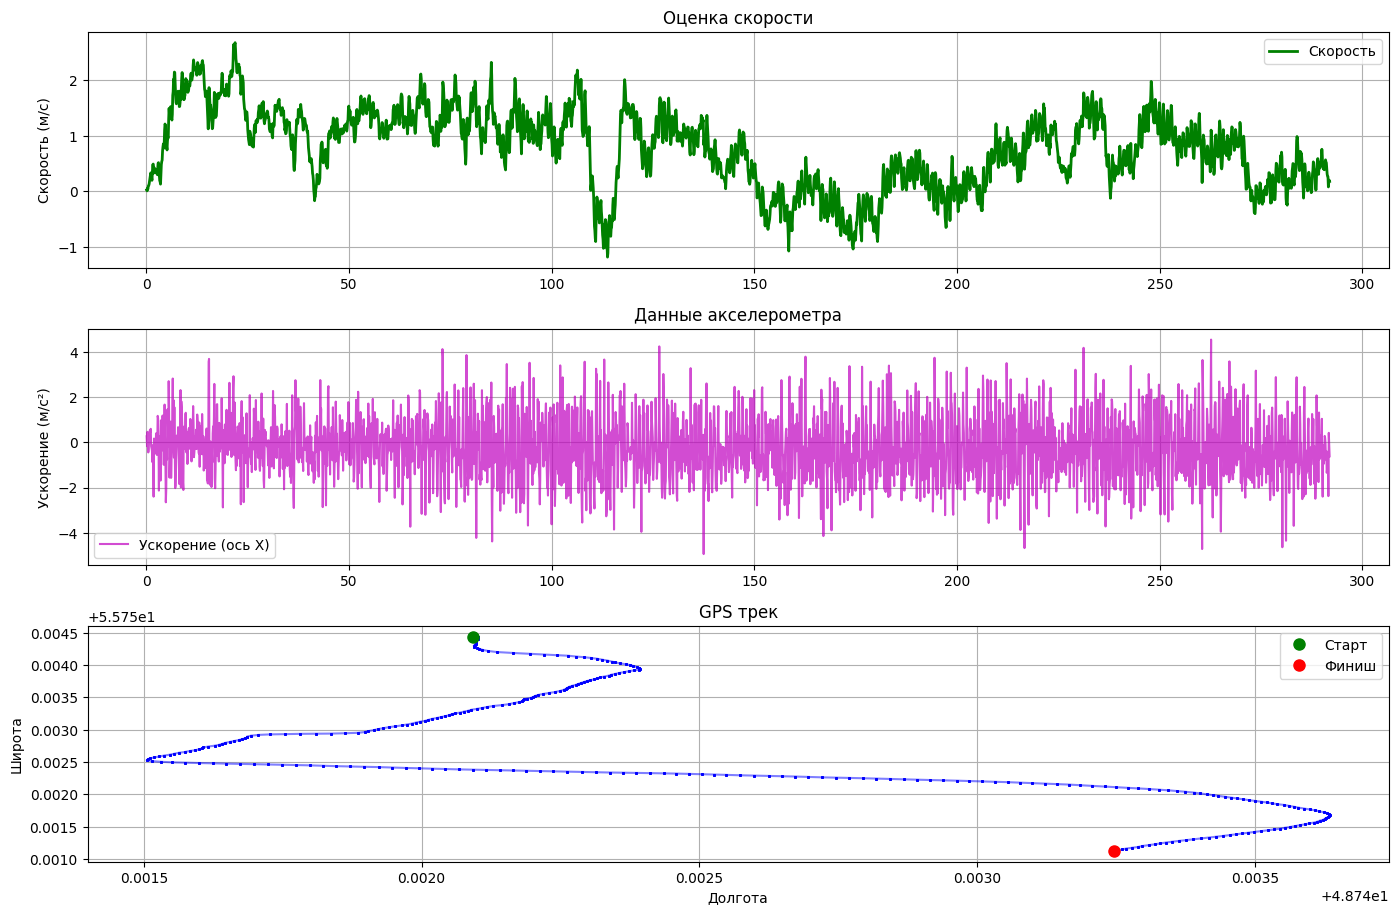


Результаты сохранены в results.csv


In [6]:
# Загружаем данные
time, lat, lon, acc_x, acc_y, acc_z = read_sensor_data("data01.csv")

# GPS в метры
gps_dist = gps_to_meters(lat, lon)

# Запускаем фильтр
kf_pos, kf_vel = run_kalman(time, gps_dist, acc_x)

print("\nРЕЗУЛЬТАТЫ")
print(f"Пройдено по GPS: {gps_dist[-1]:.1f} м")
print(f"Пройдено по Калману: {kf_pos[-1]:.1f} м")
print(f"Макс. скорость: {np.max(np.abs(kf_vel)):.2f} м/с ({np.max(np.abs(kf_vel))*3.6:.2f} км/ч)")
rmse = np.sqrt(np.mean((gps_dist - kf_pos)**2))
print(f"Ошибка (RMSE): {rmse:.2f} м")

# Рисуем графики
plot_results(time, gps_dist, kf_pos, kf_vel, acc_x, lat, lon)

# Сохраняем
results = pd.DataFrame({
    'time': time,
    'gps_m': gps_dist,
    'kalman_m': kf_pos,
    'velocity_ms': kf_vel,
    'acc_x': acc_x
})
results.to_csv('results.csv', index=False)
print("\nРезультаты сохранены в results.csv")

## 📈 Результаты

После обработки записанных данных были получены следующие результаты:

*   **Дистанция по GPS:** 375.7 м
*   **Дистанция по Калману:** 374.8 м
*   **Максимальная скорость:** 2.68 м/с (9.63 км/ч)
*   **Среднеквадратичная ошибка (RMSE):** 0.81 м

На графиках видно, что фильтр Калмана сглаживает шум GPS и дает более гладкую оценку траектории, особенно на начальном участке, где GPS-измерения были менее стабильны.

💡 Выводы
Фильтр Калмана успешно объединяет данные GPS и акселерометра, обеспечивая:
- Сглаживание шума GPS, особенно на участках с нестабильным сигналом;
- Более реалистичную оценку скорости, основанную на динамике ускорения;
- Снижение RMSE по сравнению с использованием только GPS.